In [58]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
from keras.losses import Huber

In [59]:
def plot_predictions(test, predicted):
  plt.plot(test, color='red', label='Real IBM Stock Price')
  plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
  plt.title('IBM Stock Price Prediction')
  plt.xlabel('Time')
  plt.ylabel('IBM Stock Price')
  plt.legend()
  plt.show()

def return_rmse(test, predicted):
  rmse = math.sqrt(mean_squared_error(test, predicted))
  print("-" * 30)
  print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
  print("-" * 30)

def return_mae(test, predicted):
  mae = mean_absolute_error(test, predicted)
  mape = mean_absolute_percentage_error(test, predicted) * 100
  print("Średni błąd bezwzględny {:.2f}.".format(mae))
  print("Średni błąd bezwzględny procentowy {:.2f}%".format(mape))
  print("-" * 30)

In [60]:
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [61]:
training_set = dataset[:'2016'].iloc[:,3:4].values
test_set = dataset['2017':].iloc[:,3:4].values

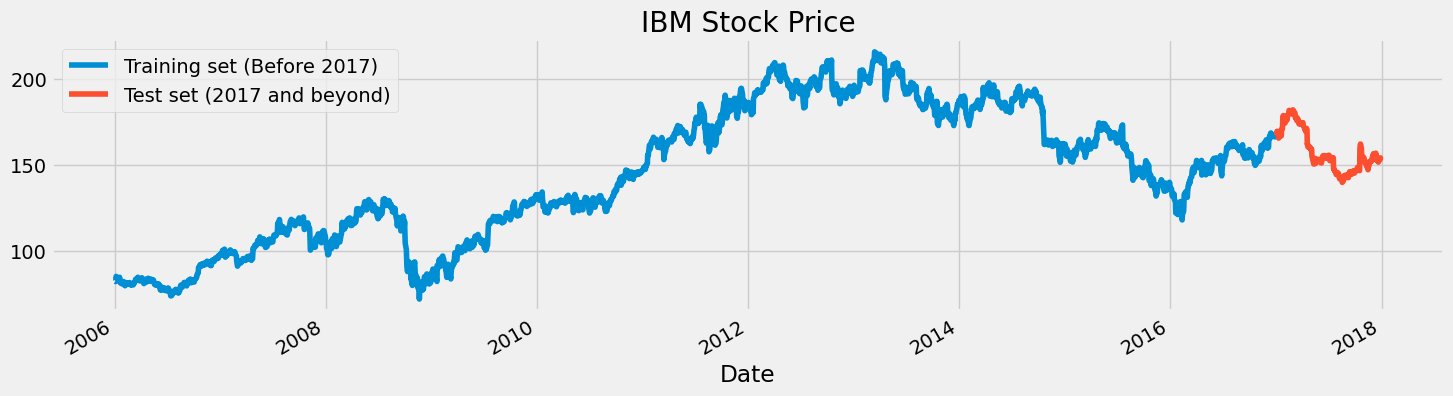

In [62]:
dataset["Close"][:'2016'].plot(figsize=(16,4), legend=True)
dataset["Close"]['2017':].plot(figsize=(16,4), legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM Stock Price')
plt.show()

In [63]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [64]:
X_train = []
y_train = []
for i in range(60, 2769):
  X_train.append(training_set_scaled[i-60:i, 0])
  y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [65]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [87]:
regressor = Sequential()
regressor.add(Input(shape=(X_train.shape[1], 1)))
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=100))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

regressor.compile(optimizer='adam', loss=Huber())
regressor.fit(X_train, y_train, epochs=100, batch_size=32)

#early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#regressor.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0103
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0017
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0018
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0015
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0015
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0015
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0013
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0012
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0013
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0012
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0010
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - lo

In [88]:
dataset_total = pd.concat((dataset["Close"][:'2016'], dataset["Close"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [89]:
X_test = []
for i in range(60, 311):
  X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


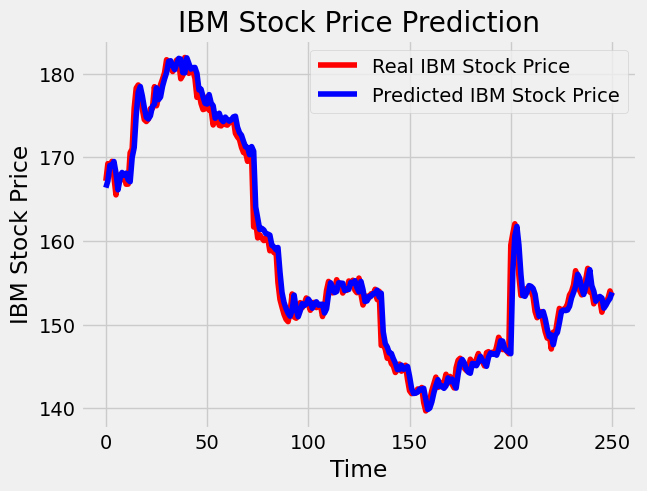

In [90]:
plot_predictions(test_set, predicted_stock_price)

In [91]:
return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 1.66.
------------------------------
Średni błąd bezwzględny 1.08.
Średni błąd bezwzględny procentowy 0.68%
------------------------------


In [100]:
regressorGRU = Sequential()
regressorGRU.add(Input(shape=(X_train.shape[1], 1)))
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=100, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(Dense(units=1))

regressorGRU.compile(optimizer='adam', loss=Huber())
regressorGRU.fit(X_train, y_train, epochs=100, batch_size=32)

#early_stop_gru = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#regressorGRU.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop_gru])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0067
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0010
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.6290e-04
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 9.2389e-04
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 9.3417e-04
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.4069e-04
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.8044e-04
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.7663e-04
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.8330e-04
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.6914e-04
Epoch 15/100
85/85 ━━━━━━

In [101]:
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


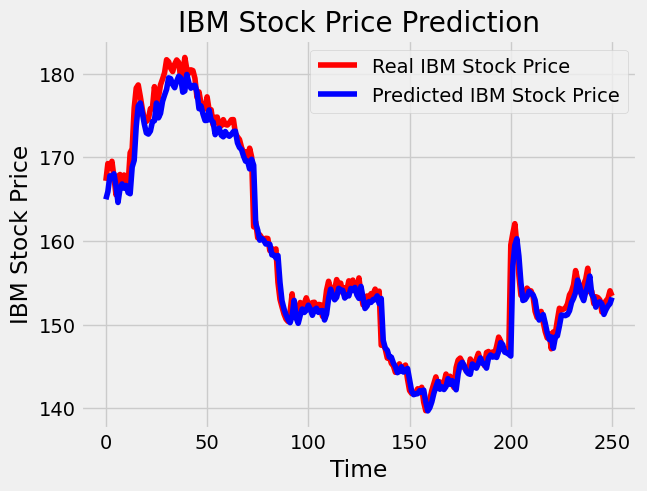

In [102]:
plot_predictions(test_set, GRU_predicted_stock_price)

In [103]:
return_rmse(test_set, GRU_predicted_stock_price)
return_mae(test_set, GRU_predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 1.80.
------------------------------
Średni błąd bezwzględny 1.23.
Średni błąd bezwzględny procentowy 0.76%
------------------------------
